In [150]:
# SimPEG functionality
from simpeg import maps, utils, data, optimization, maps, regularization, directives
from simpeg.electromagnetics import natural_source as nsem
from simpeg.utils import model_builder

# discretize functionality
from discretize import TreeMesh
from discretize.utils import mkvc, active_from_xyz

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Define the topography

In [ ]:
x_topo, y_topo = np.meshgrid(
    np.linspace(-14000, 14000, 200), np.linspace(-14000, 14000, 200)
)
z_topo = np.zeros((len(x_topo), len(y_topo)))

x_topo, y_topo, z_topo = mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)
topo_xyz = np.c_[mkvc(x_topo), mkvc(y_topo), mkvc(z_topo)]

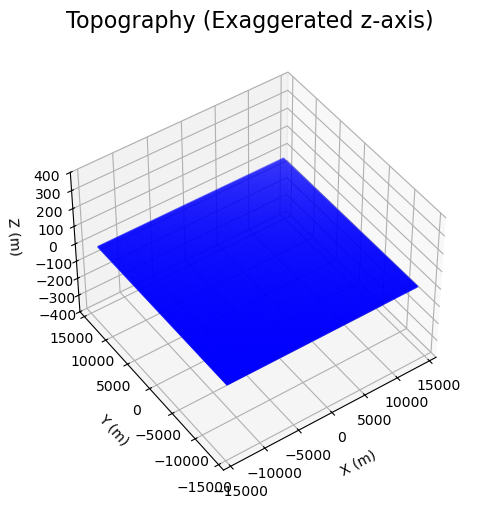

In [3]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([-400, 400])
ax.scatter3D(topo_xyz[:, 0], topo_xyz[:, 1], topo_xyz[:, 2], s=0.25, c="b")
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=45.0, azim=-125)

# Setup Reciever Locations

In [4]:
x_positions = [
    -5000, -2000, -1500, -1000, -750, -500, -400, -300, -250, -200,
    -150, -125, -100, -90, -80, -70, -60, -50, -40, -30,
    -20, -10, 0, 10, 20, 30, 40, 50, 60, 70,
    80, 90, 100, 125, 150, 200, 250, 300, 400, 500,
    750, 1000, 1500, 2000, 5000
]

y_positions = [
    -5000, -2000, -1500, -1000, -750, -500, -400, -300, -250, -200,
    -150, -125, -100, -90, -80, -70, -60, -50, -40, -30,
    -20, -10, 0, 10, 20, 30, 40, 50, 60, 70,
    80, 90, 100, 125, 150, 200, 250, 300, 400, 500,
    750, 1000, 1500, 2000, 5000
]

rx_locs = []

for x in x_positions:
    for y in y_positions:
        rx_locs.append([x, y, 0]) 

rx_locs = np.array(rx_locs)
print(rx_locs.shape)

(2025, 3)


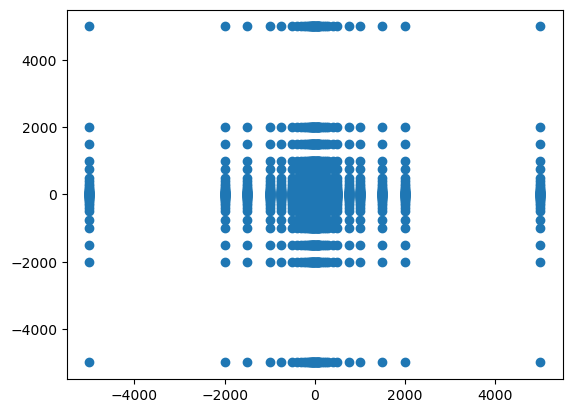

In [5]:
plt.scatter(rx_locs[:,0], rx_locs[:,1])

# Define Mesh

In [ ]:
dh = 50  # fine cell size

# Skin depth at 0.001 Hz ~ 500 km, use 5x = 2500 km
dom_width_x = 500000.0  # 500 km
dom_width_y = 500000.0  # 500 km
dom_width_z = 500000.0  # 500 km

nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))
nbcy = 2 ** int(np.round(np.log(dom_width_y / dh) / np.log(2.0)))
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))

hx = [(dh, nbcx)]
hy = [(dh, nbcy)]
hz = [(dh, nbcz)]
mesh = TreeMesh([hx, hy, hz], x0="CCN", diagonal_balance=True)

# Coarse refinement over the whole domain first
mesh.refine_box(
    [-250000, -250000, -250000],
    [250000, 250000, 0],
    levels=2,
    finalize=False
)

# Medium refinement in the core region
mesh.refine_box(
    [-10000, -10000, -5000],
    [10000, 10000, 0],
    levels=4,
    finalize=False
)

# Fine refinement near receivers
refine_pts = np.zeros((len(rx_locs), 3))
for i, pt in enumerate(rx_locs):
    refine_pts[i] = [pt[0], pt[1], 0]
mesh.refine_points(refine_pts, padding_cells_by_level=[2, 1], finalize=False)

# Fine refinement around sphere
mesh.refine_points([[0, 0, -1000]], padding_cells_by_level=[4, 3, 2, 1], finalize=False)

mesh.finalize()
print(f"Mesh cells: {mesh.nC:,}")
print(f"Mesh x extent: {mesh.nodes_x[[0,-1]]/1000} km")
print(f"Mesh z extent: {mesh.nodes_z[[0,-1]]/1000} km")

Mesh cells: 21,288
Mesh x extent: [-204.8  204.8] km
Mesh z extent: [-409.6    0. ] km


# Setup Model

In [153]:
active_cells = active_from_xyz(mesh, topo_xyz)
n_active = np.sum(active_cells)
active_map = maps.InjectActiveCells(mesh, active_cells, 1e-8)

background_conductivity = 0.001
sphere_conductivity = 10

background_model = background_conductivity * np.ones(n_active)
background_model_full = active_map * background_model

sphere_indices = model_builder.get_indices_sphere(center=[0,0,-1000], radius=500, cell_centers=mesh.cell_centers[active_cells, :])
conductivity_model = background_model_full.copy()
conductivity_model[sphere_indices] = sphere_conductivity


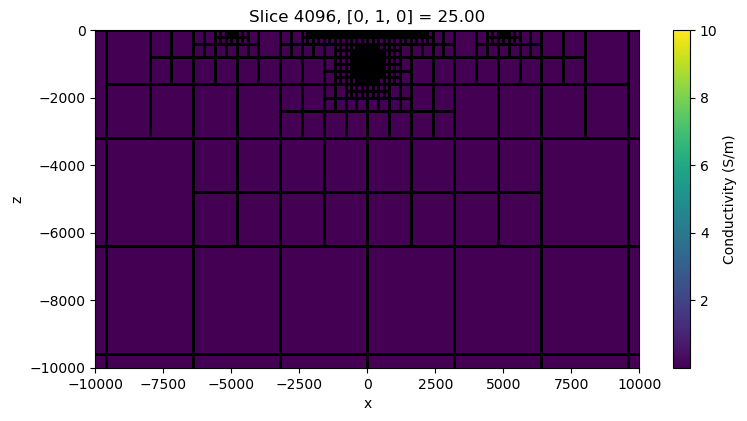

In [161]:
plotting_map = maps.InjectActiveCells(mesh, active_cells, np.nan)

fig = plt.figure(figsize=(10, 4.5))

ax1 = fig.add_axes([0.15, 0.15, 0.68, 0.75])
out = mesh.plot_slice(
    conductivity_model,
    ax=ax1,
    normal="Y",
    ind=int(len(mesh.h[1]) / 2),
    grid=True,
    pcolor_opts={"cmap": "viridis"}
)

cb = plt.colorbar(out[0], ax=ax1, orientation='vertical')
cb.set_label('Conductivity (S/m)')

ax1.set_xlim([-10000, 10000])
ax1.set_ylim([-10000, 0])
plt.show()

# Setup frequencies and survey

In [155]:
low_freq = 0.001
high_freq = 10000
samples_per_dec = 10

freqs = np.logspace(-3, 4, 10*7+1)

source_list = []

for f in freqs:
    rx_list = [
        nsem.receivers.Impedance(rx_locs, orientation='xy', component='real'),
        nsem.receivers.Impedance(rx_locs, orientation='xy', component='imag'),
        nsem.receivers.Impedance(rx_locs, orientation='yx', component='real'),
        nsem.receivers.Impedance(rx_locs, orientation='yx', component='imag'),
    ]
    
    source_list.append(nsem.sources.PlanewaveXYPrimary(rx_list, frequency=f, sigma_primary=background_model))

survey = nsem.survey.Survey(source_list)

In [172]:
print(len(survey.source_list))

71


# Setup and Run Sim

In [156]:
sim = nsem.Simulation3DPrimarySecondary(
    mesh,
    survey=survey,
    sigmaMap=active_map,
    sigmaPrimary=background_model_full,
    forward_only=True
)
sim.model = conductivity_model

dpred = sim.dpred(conductivity_model)
print("Expected data shape:", len(freqs) * len(rx_locs) * 4)
print("Survey data shape:", dpred.shape)

c:\Users\ryds1\miniconda3\envs\simpeg-mt-env\lib\site-packages\simpeg\base\pde_simulation.py:490: DefaultSolverWarning: Using the default solver: Pardiso. 

If you would like to suppress this notification, add 
warnings.filterwarnings('ignore', simpeg.utils.solver_utils.DefaultSolverWarning)
 to your script.
  return get_default_solver(warn=True)


Expected data shape: 575100
Survey data shape: (575100,)


In [ ]:
# debug block

n_rx = len(rx_locs)
Z_xy_real = dpred[0::4]
Z_xy_imag = dpred[1::4]
Z_xy = (Z_xy_real + 1j * Z_xy_imag).reshape(len(freqs), n_rx)

mu_0 = 4 * np.pi * 1e-7
print(f"{'Freq (Hz)':<12} {'|Z| mean':<12} {'Phase (°)':<12} {'Expected |Z|':<12}")
print("-" * 50)
for i in [0, len(freqs)//4, len(freqs)//2, 3*len(freqs)//4, -1]:
    omega_i = 2 * np.pi * freqs[i]
    Z_exp = np.sqrt(1j * omega_i * mu_0 / background_conductivity)
    print(f"{freqs[i]:<12.4f} "
          f"{np.abs(Z_xy[i]).mean():<12.6f} "
          f"{np.angle(Z_xy[i], deg=True).mean():<12.1f} "
          f"{np.abs(Z_exp):<12.6f}")

Freq (Hz)    |Z| mean     Phase (°)    Expected |Z|
--------------------------------------------------
0.0010       0.000000     -43.2        0.002810    
0.0501       0.000008     -43.3        0.019893    
3.1623       0.000523     -43.5        0.158014    
199.5262     0.033816     -43.3        1.255148    
10000.0000   1.835839     -45.0        8.885766    


# Visualize and plot data

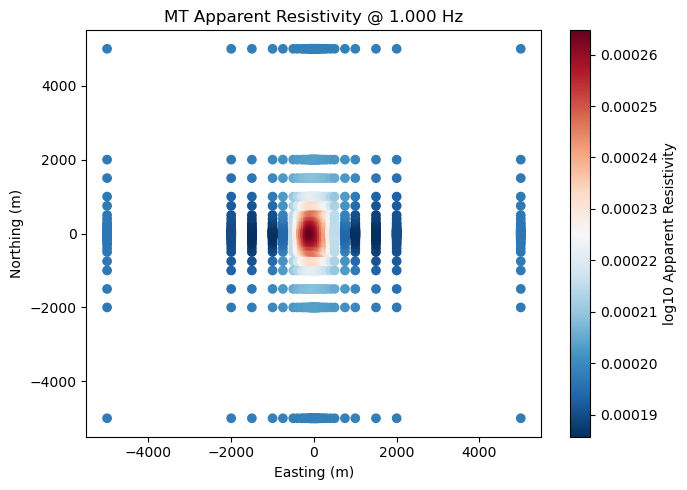

In [158]:
# Reshape apparent resistivity for a single frequency
freq_idx = 30  # pick a frequency index
n_rx = len(rx_locs)

rho_xy = np.abs(dpred.reshape(len(freqs), 4, len(rx_locs)))

plt.figure(figsize=(7, 5))
plt.scatter(rx_locs[:, 0], rx_locs[:, 1], c=(rho_xy[freq_idx, 1]), cmap='RdBu_r')
plt.colorbar(label='log10 Apparent Resistivity')
plt.title(f'MT Apparent Resistivity @ {freqs[freq_idx]:.3f} Hz')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.tight_layout()
plt.show()

In [ ]:
print(np.min(conductivity_model))

0.001


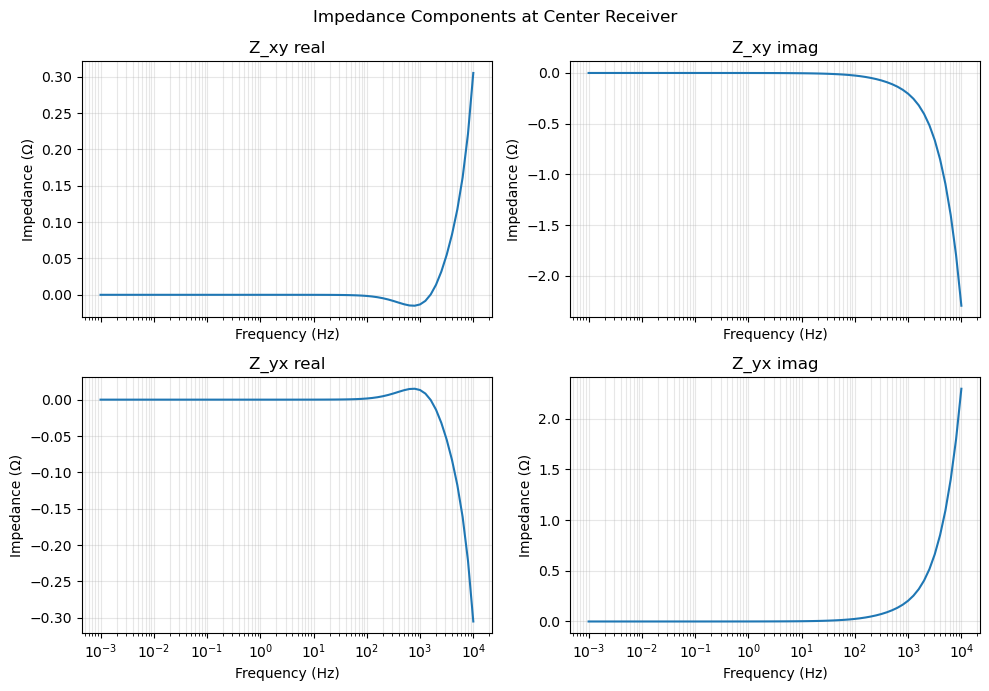

In [159]:
z_vals = dpred.reshape(len(freqs), 4, len(rx_locs))

z_center = z_vals[:, :, 1012]

labels = ['Z_xy real', 'Z_xy imag', 'Z_yx real', 'Z_yx imag']

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
axes = axes.flatten()

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.semilogx(freqs, z_center[:, i])
    ax.set_title(label)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Impedance (Ω)')
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Impedance Components at Center Receiver')
plt.tight_layout()
plt.show()

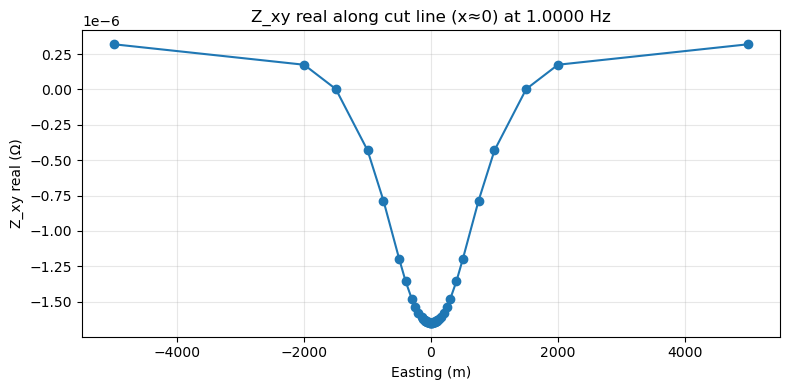

In [160]:
freq_idx = 30

# Define a cut line — e.g. y=0, varying x
# Find receivers closest to y=0

cut_vals = z_vals[freq_idx, 0, 990:1035]  # Z_xy real

x_cut = rx_locs[990:1035, 1]
y_cut = rx_locs[990:1035, 0]

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_cut, cut_vals, 'o-')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Z_xy real (Ω)')
ax.set_title(f'Z_xy real along cut line (x≈0) at {freqs[freq_idx]:.4f} Hz')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [168]:
mu0 = 4 * np.pi * 1e-7
omega = 2 * np.pi * freqs[:, None]

Zxy = z_vals[:, 0, :] + 1j * z_vals[:, 1, :]
Zyx = z_vals[:, 2, :] + 1j * z_vals[:, 3, :]

# apparent resistivities
rho_xy = np.abs(Zxy)**2 / (mu0 * omega)
rho_yx = np.abs(Zyx)**2 / (mu0 * omega)

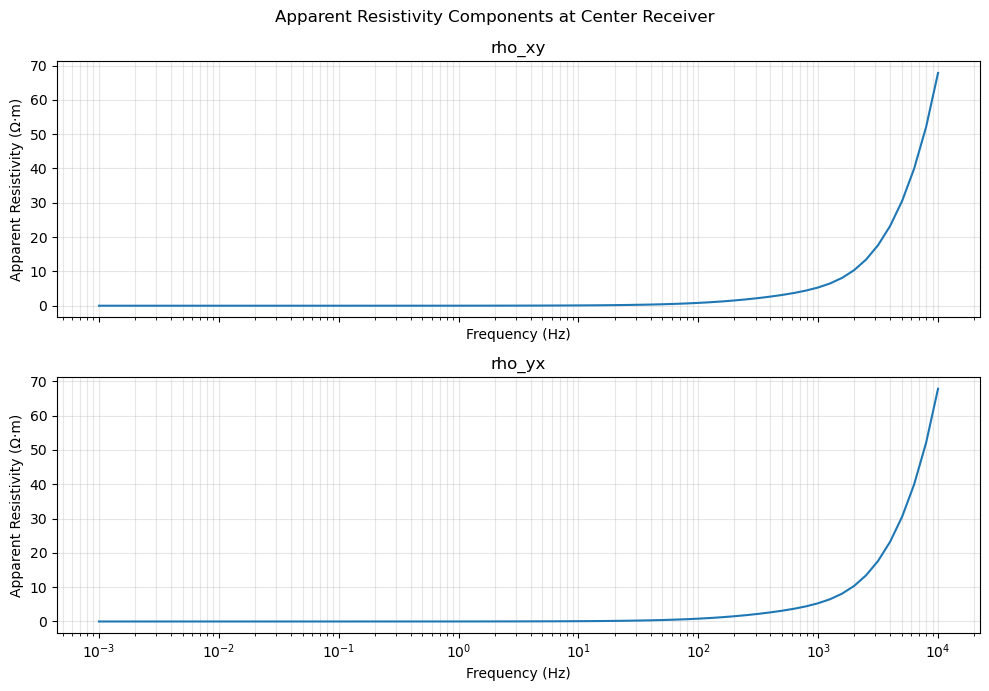

In [169]:
labels = ['rho_xy', 'rho_yx']

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

rx_idx = 1012

axes[0].semilogx(freqs, rho_xy[:, rx_idx])
axes[0].set_title(labels[0])
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Apparent Resistivity (Ω·m)')
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogx(freqs, rho_yx[:, rx_idx])
axes[1].set_title(labels[1])
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Apparent Resistivity (Ω·m)')
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Apparent Resistivity Components at Center Receiver')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

with open('Zdata.pkl', 'wb') as f:
    pickle.dump(z_vals, f)

with open('ZdataPred.pkl', 'wb') as f:
    pickle.dump(dpred, f)